In [60]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from experiments.make_basic_rnn_model import utilities

In [61]:
data = pd.read_csv('wz_rnn_gridsearch.csv')
data['real_bit_rate']=data['real_bit_rate'].apply(lambda x: eval(x[6:]) if x[:6]=='tensor' else eval(None))

In [62]:
temp = np.random.normal(0, np.sqrt(1), 1_000_000, ).astype(np.float32)
y = temp + np.random.normal(0, np.sqrt(0.01), 1_000_000, ).astype(np.float32)
side_info_data = [temp]
side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

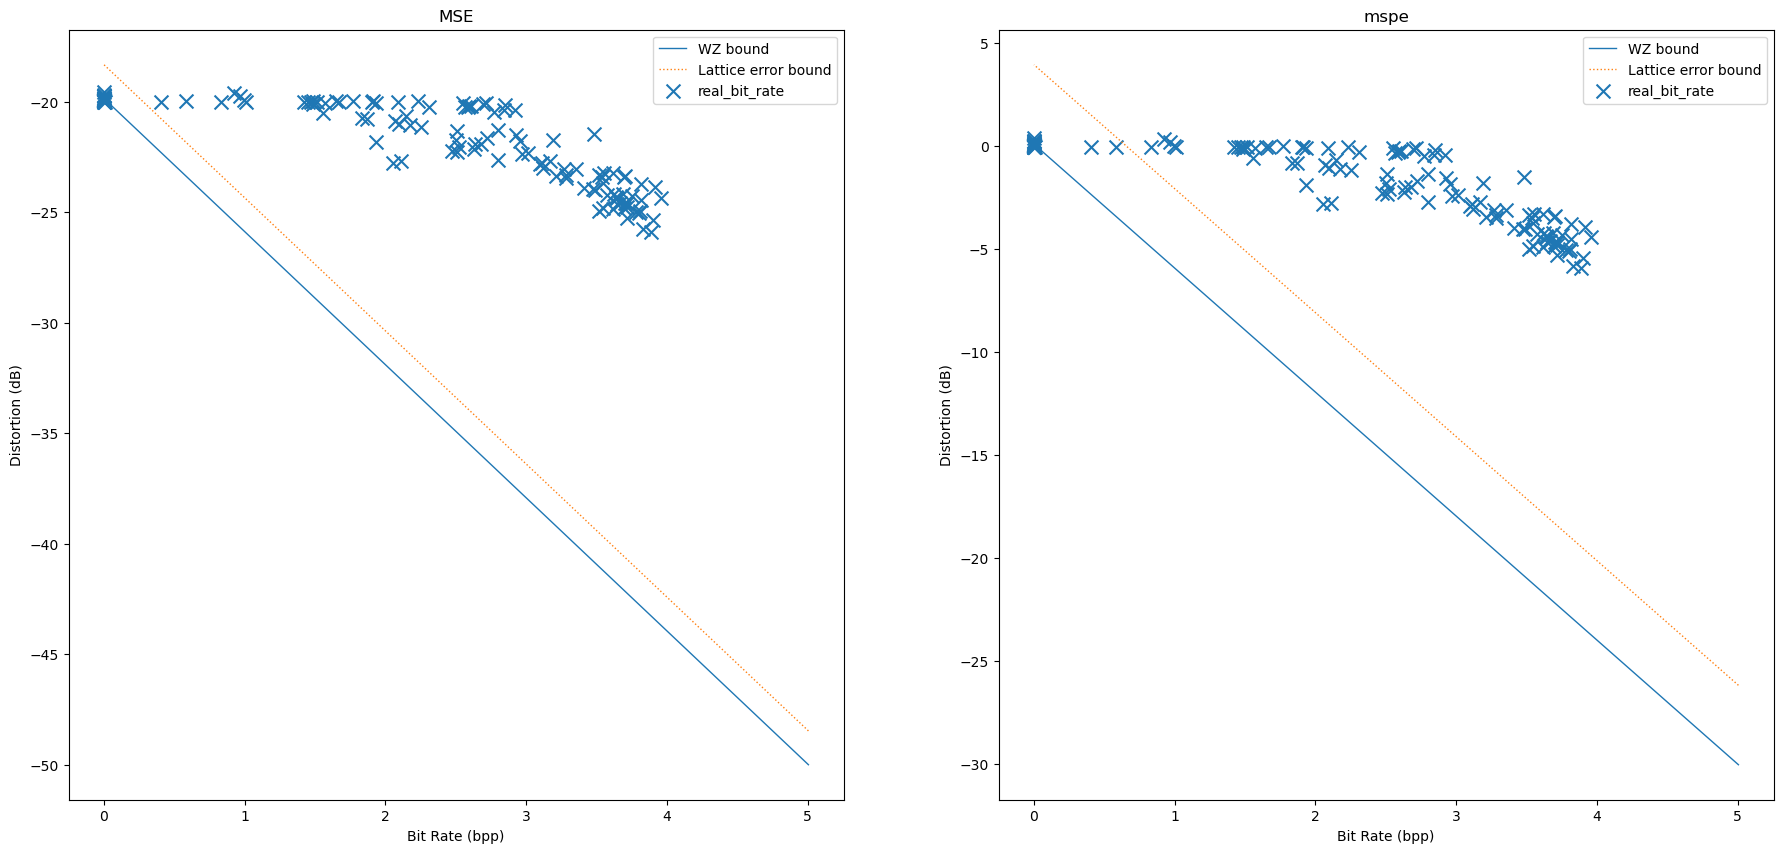

In [64]:
fig, axes = plt.subplots(1,2, figsize=(22, 10))
for i, ax in enumerate(axes):
    bound_x_y = utilities.bound_lines(y, side_info_variance, noise_variance, mape_flag=(i==1))
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1]+bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    # for mk, br in [('s', 'softcodes_bit_rate'), ('o', 'prior_bit_rate'), ('x','real_bit_rate'),]:
    #     ax.scatter(eval(br), 10 * np.log10(mse if i == 0 else mspe), label=br, s=100, marker=mk)
    ax.scatter(data['real_bit_rate'], 10 * np.log10(data['mse'] if i == 0 else data['mspe']),
               label='real_bit_rate', s=100, marker='x')

    ax.set_xlabel('Bit Rate (bpp)')
    ax.set_ylabel('Distortion (dB)')
    # ax.grid(True)
    ax.legend()
axes[0].set_title('MSE')
axes[1].set_title('mspe')
plt.show()

In [65]:
def plot(results, first_name='tau', second_name='lr', t_name='efctv_bit_rate'):
    target_names = ['MAPE% (db)', t_name]
    x_axis = results[f'params_{first_name}']
    y_axis = results[f'params_{second_name}']
    temp = np.log10(results['value']) * 10
    z_axis = [temp, results[f'user_attrs_{target_names[1]}']]

    x_lim = [(a.min()-0.1,a.max()+0.1) for a in (x_axis, y_axis)]
    # x_lim[0] = (10, 10)
    # x_lim[1] = (0, 5)

    # Create 2D heat maps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, z in enumerate(z_axis):
        ax = axes[i]
        im = ax.hexbin(x_axis, y_axis, C=z, gridsize=30, cmap='viridis', mincnt=1)
        ax.set_xlabel(first_name)
        ax.set_ylabel(second_name)
        ax.set_title(f'Optimization Results Heat Map for {target_names[i]}')
        fig.colorbar(im, ax=ax, label=target_names[i])

    plt.tight_layout()
    plt.show()

    # Create individual parameter plots
    param_names = [first_name, second_name]
    param_data = [x_axis, y_axis]

    for param_idx, (param_name, param_values) in enumerate(zip(param_names, param_data)):
        for i, z in enumerate(z_axis):
            plt.figure(figsize=(15, 4))

            # Sort by parameter values for better visualization
            sorted_indices = np.argsort(param_values)
            sorted_x = param_values.iloc[sorted_indices]
            sorted_y = z.iloc[sorted_indices]


            # Scatter plot of the data points
            plt.scatter(sorted_x, sorted_y, label=param_name, marker='o', alpha=0.6, s=15)

            # Calculate and plot the mean line with std deviation
            bins = np.linspace(sorted_x.min(), sorted_x.max(), 15)
            digitized = np.digitize(sorted_x, bins)
            bin_means = [sorted_y[digitized == j].mean() for j in range(1, len(bins))]
            bin_stds = [sorted_y[digitized == j].std() for j in range(1, len(bins))]
            bin_centers = (bins[:-1] + bins[1:]) / 2

            bin_means = np.array(bin_means)
            bin_stds = np.array(bin_stds)

            plt.plot(bin_centers, bin_means, color='red', linewidth=2, label='Mean Trend')
            plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds,
                             color='red', alpha=0.2, label='Std Dev')

            plt.xlabel(param_name)
            plt.ylabel(target_names[i])
            plt.title(f'{param_name} vs {target_names[i]}')
            plt.grid(True, alpha=0.3)
            plt.xlim(x_lim[param_idx])
            plt.legend()
            plt.show()
